# Time Series Analysis
##### A Time series data is collected over the time

###### Data Order Matters -> You can not shuffle the data

##### Components of Time Series (VERY IMPORTANT)
- Trend   (Long-Term Increase/Decrease)
- Seasonality  (Repeating Pattern)
- Cyclic  (Irregular long cycles)
- Noise   (Random Variation)

#### Stationarity
- Mean is constant
- Varianve is constant
- No Trend/Seasonality

##### Using ADF you can check Stationarity
- p-value < 0.05 Stationary
- p-value > 0.05 Not- Stationary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create Data Range
dates = pd.date_range( start='2025-1-1' , periods=365 , freq="D" )
dates[:5]

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05'],
              dtype='datetime64[ns]', freq='D')

In [3]:
# Create Components
trend = np.linspace(10,100,365)
season = 10*np.sin( np.linspace(0,50,365) )
noise = np.random.normal( 0,5,365 )  
value = trend+season+noise
value[:10]

array([ 5.87468628, 19.56981489, 11.04225145, 15.1259665 , 20.26592781,
       17.5487602 , 20.03808414, 18.7749505 , 18.46263753, 25.88324195])

In [4]:
df = pd.DataFrame({
    'Date':dates , 
    'Price':value
})

In [5]:
df.head(10)

,Date,Price
0,2025-01-01,5.874686
1,2025-01-02,19.569815
2,2025-01-03,11.042251
3,2025-01-04,15.125967
4,2025-01-05,20.265928
5,2025-01-06,17.548760
6,2025-01-07,20.038084
7,2025-01-08,18.774950
8,2025-01-09,18.462638
9,2025-01-10,25.883242


In [6]:
df = df.set_index('Date')

In [7]:
df.head(10)

,Price
Date,
2025-01-01,5.874686
2025-01-02,19.569815
2025-01-03,11.042251
2025-01-04,15.125967
2025-01-05,20.265928
2025-01-06,17.548760
2025-01-07,20.038084
2025-01-08,18.774950
2025-01-09,18.462638


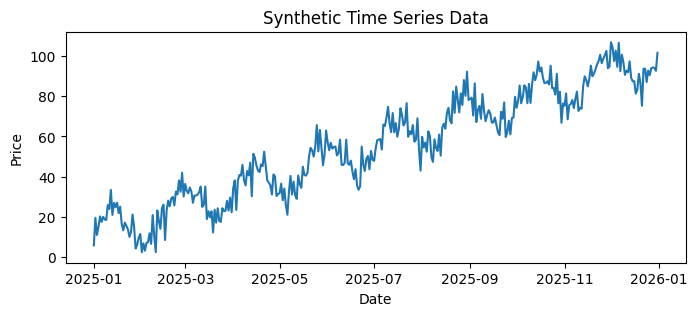

In [8]:
plt.figure(figsize=(8,3))
plt.plot(df.index ,  df['Price'] )
plt.title("Synthetic Time Series Data")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [9]:
df.head(2)

,Price
Date,
2025-01-01,5.874686
2025-01-02,19.569815


#### Decompose The Time Series

In [14]:
# !pip install statsmodels

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [12]:
decompose = seasonal_decompose( df['Price'] , model='additive' , period=30 )

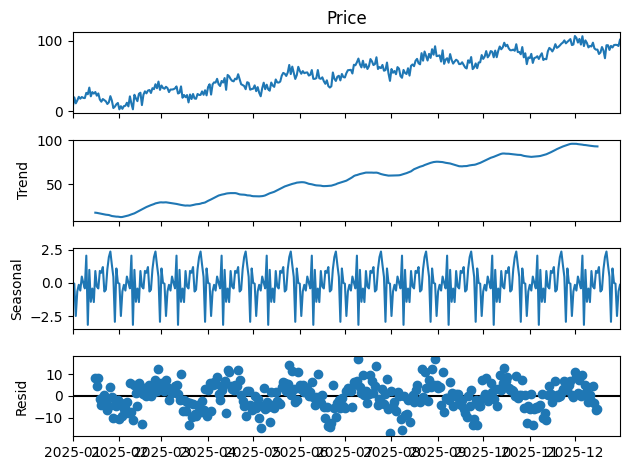

In [13]:
decompose.plot()
plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller

In [16]:
result = adfuller(df['Price'])

In [18]:
print("P-Value : ",result[1])

P-Value :  0.7278763670901862


In [19]:
## p-value > 0.05 => Not_stationary

In [21]:
df['diff'] = df['Price'].diff()
df.head(3)

,Price,diff
Date,,
2025-01-01,5.874686,NaN
2025-01-02,19.569815,13.695129
2025-01-03,11.042251,-8.527563


In [22]:
df = df.dropna()

In [23]:
df.head(3)

,Price,diff
Date,,
2025-01-02,19.569815,13.695129
2025-01-03,11.042251,-8.527563
2025-01-04,15.125967,4.083715


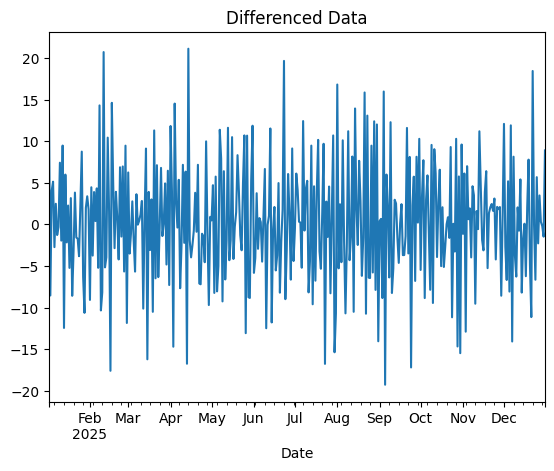

In [25]:
df['diff'].plot(title='Differenced Data')
plt.show()

In [26]:
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf

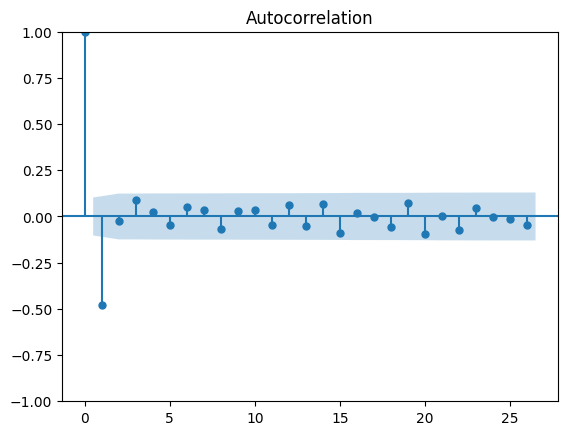

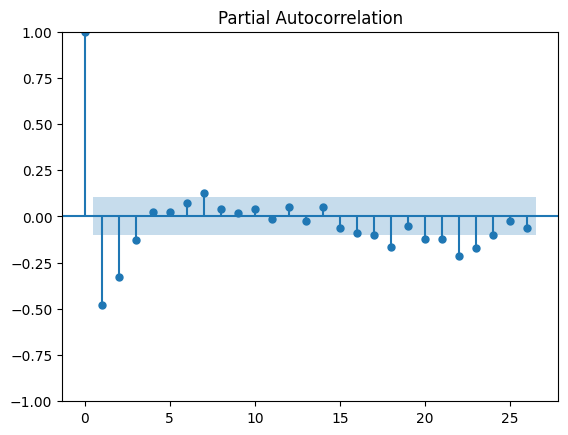

In [28]:
plot_acf(df['diff'])
plot_pacf(df['diff'])
plt.show()

In [29]:
from statsmodels.tsa.arima.model import ARIMA

In [30]:
model = ARIMA( df['Price'] , order=(1,1,1) )
model = model.fit()

C:\Users\Croma Campus\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Croma Campus\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Croma Campus\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [40]:
forecast = model.forecast( steps=20 )

In [41]:
forecast

2026-01-01    96.002320
2026-01-02    96.944303
2026-01-03    96.782699
2026-01-04    96.810423
2026-01-05    96.805667
2026-01-06    96.806483
2026-01-07    96.806343
2026-01-08    96.806367
2026-01-09    96.806363
2026-01-10    96.806364
2026-01-11    96.806364
2026-01-12    96.806364
2026-01-13    96.806364
2026-01-14    96.806364
2026-01-15    96.806364
2026-01-16    96.806364
2026-01-17    96.806364
2026-01-18    96.806364
2026-01-19    96.806364
2026-01-20    96.806364
Freq: D, Name: predicted_mean, dtype: float64

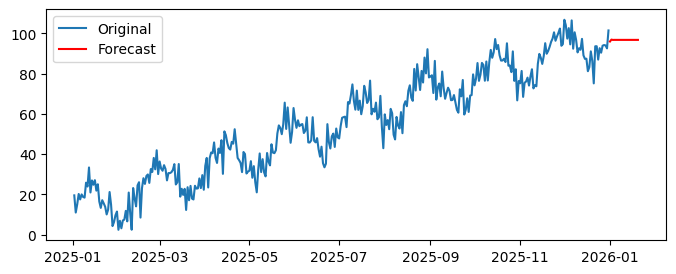

In [42]:
plt.figure( figsize=(8,3) )
plt.plot(df['Price'] , label="Original")
plt.plot(forecast , label="Forecast" , color='red')
plt.legend()
plt.show()

In [43]:
model = ARIMA( df['diff'] , order=(1,1,1) )
model = model.fit()
forecast = model.forecast( steps=20 )

C:\Users\Croma Campus\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Croma Campus\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Croma Campus\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Croma Campus\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


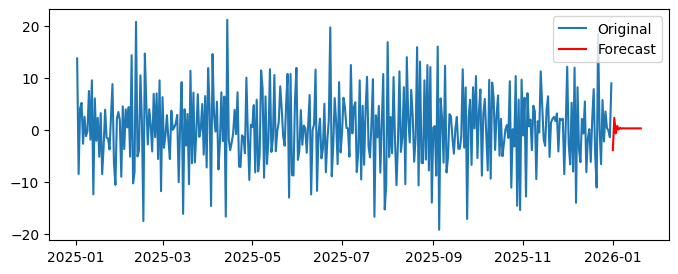

In [45]:
plt.figure( figsize=(8,3) )
plt.plot(df['diff'] , label="Original")
plt.plot(forecast , label="Forecast" , color='red')
plt.legend()
plt.show()

In [46]:
forecast

2026-01-01   -3.937327
2026-01-02    2.261959
2026-01-03   -0.732293
2026-01-04    0.713929
2026-01-05    0.015405
2026-01-06    0.352792
2026-01-07    0.189834
2026-01-08    0.268543
2026-01-09    0.230526
2026-01-10    0.248888
2026-01-11    0.240019
2026-01-12    0.244303
2026-01-13    0.242234
2026-01-14    0.243233
2026-01-15    0.242751
2026-01-16    0.242984
2026-01-17    0.242871
2026-01-18    0.242926
2026-01-19    0.242899
2026-01-20    0.242912
Freq: D, Name: predicted_mean, dtype: float64

In [47]:
# HW - SARIMAX